<a href="https://colab.research.google.com/github/KhusbuBubna123/Twitter-Sentiment-Analysis-1/blob/main/TwitterSentimentAnalysis_Multinomial_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score,f1_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df= pd.read_csv("/content/drive/MyDrive/Twitter_Data_Multiclass.csv",sep=',',names=['Tweet','Sentiment'],encoding='latin-1')
df.head(50)
#negative(-1), neutral(0), and positive(+1).
#-1-Negative,
#0-Neutral
#+1-Positive(+1).

,Tweet,Sentiment
0,clean_text,category
1,when modi promised âminimum government maxim...,-1
2,talk all the nonsense and continue all the dra...,0
3,what did just say vote for modi welcome bjp t...,1
4,asking his supporters prefix chowkidar their n...,1
5,answer who among these the most powerful world...,1
6,kiya tho refresh maarkefir comment karo,0
7,surat women perform yagna seeks divine grace f...,0
8,this comes from cabinet which has scholars lik...,0
9,with upcoming election india saga going import...,1


In [4]:
df = df.drop(df.index[0])

In [5]:
df.head()

,Tweet,Sentiment
1,when modi promised âminimum government maxim...,-1
2,talk all the nonsense and continue all the dra...,0
3,what did just say vote for modi welcome bjp t...,1
4,asking his supporters prefix chowkidar their n...,1
5,answer who among these the most powerful world...,1


In [6]:
df.tail()

,Tweet,Sentiment
162976,why these 456 crores paid neerav modi not reco...,-1
162977,dear rss terrorist payal gawar what about modi...,-1
162978,did you cover her interaction forum where she ...,0
162979,there big project came into india modi dream p...,0
162980,have you ever listen about like gurukul where ...,1


In [7]:
df.shape

(162980, 2)

In [8]:
df.columns

Index(['Tweet', 'Sentiment'], dtype='object')

In [ ]:
#pd.set_option('display.max_rows', None)

#Exporatory Data Anlysis.

#Detecting Missing Values.

In [9]:
df.isnull().sum()

,0
Tweet,4
Sentiment,7


In [10]:
df.describe(include='all')

,Tweet,Sentiment
count,162976,162973
unique,162976,3
top,never seen duffer person like you want modi no...,1
freq,1,72250


In [11]:
df.dtypes

,0
Tweet,object
Sentiment,object


#Null Value Imputation.

In [12]:
df.loc[df['Sentiment'].isnull(),'Sentiment']=df['Sentiment'].mode()
#df.loc[df['Tweet'].isnull(),'Tweet']=df['Tweet'].mode()
df.loc[df['Tweet'].isnull(),'Tweet']="never seen duffer person like you want modi not vasundhra you remember what loksabha and what vidhansabha"

df['Sentiment']=df['Sentiment'].fillna(df['Sentiment'].mode())
#df['Tweet']=df['Tweet'].fillna(df['Tweet'].mode())
df['Tweet']=df['Tweet'].fillna("never seen duffer person like you want modi not vasundhra you remember what loksabha and what vidhansabha")

In [13]:
#df['Sentiment'].value_counts()

#-1-Negative,
#0-Neutral
#+1-Positive(+1).

#Negative Sentiments

In [15]:
df.loc[df['Sentiment'] == '-1']

,Tweet,Sentiment
1,when modi promised âminimum government maxim...,-1
16,vote such party and leadershipwho can take fas...,-1
20,didnâ write chowkidar does mean â anti mod...,-1
22,with firm belief the leadership shri narendra ...,-1
24,sultanpur uttar pradesh loksabha candidate sel...,-1
...,...,...
162957,when narender modi contested two seats was not...,-1
162963,modi decimates congress front crores congress ...,-1
162968,azamgarh please poor working requirement jogia...,-1
162976,why these 456 crores paid neerav modi not reco...,-1


#Positive Sentiments.

In [16]:
df.loc[df['Sentiment'] == '1']

,Tweet,Sentiment
3,what did just say vote for modi welcome bjp t...,1
4,asking his supporters prefix chowkidar their n...,1
5,answer who among these the most powerful world...,1
9,with upcoming election india saga going import...,1
10,gandhi was gay does modi,1
...,...,...
162970,objective cover everything from akhlaq ramalin...,1
162971,raga knows dat wont spared modi courts for his...,1
162973,engine growth modi unveils indias first 12000 ...,1
162974,modi promised 2014 lok sabha elections that be...,1


#Neutral Sentiments.

In [20]:
df.loc[df['Sentiment'] == '0']

,Tweet,Sentiment,Tweet_Length
2,talk all the nonsense and continue all the dra...,0,68
6,kiya tho refresh maarkefir comment karo,0,40
7,surat women perform yagna seeks divine grace f...,0,76
8,this comes from cabinet which has scholars lik...,0,84
14,one vote can make all the difference anil kapo...,0,128
...,...,...,...
162969,case dont look candidate then that case person...,0,236
162972,congress veteran sudhakar reddy joins bjp afte...,0,61
162975,save your agenda peddling â had with terror ...,0,251
162978,did you cover her interaction forum where she ...,0,51


# Calculating Tweet lengths.

In [21]:
#df = df.drop(columns='Length')
df['Tweet_Length'] = df['Tweet'].astype(str).apply(len)
df.head()

,Tweet,Sentiment,Tweet_Length
1,when modi promised âminimum government maxim...,-1,214
2,talk all the nonsense and continue all the dra...,0,68
3,what did just say vote for modi welcome bjp t...,1,117
4,asking his supporters prefix chowkidar their n...,1,212
5,answer who among these the most powerful world...,1,81


In [22]:
# Longest Tweet
max_length=df['Tweet_Length'].max()
df.loc[df['Tweet_Length'] == df['Tweet_Length'].max(),'Tweet'].values[0]

'â\x96¬â\x96¬â\x96¬â\x97\x99â\x96¬â\x96¬â\x96¬\nâ\x95\x90â\x96\x82â\x96\x84â\x96\x84â\x96\x93â\x96\x84â\x96\x84â\x96\x82 â\x97¢â\x97¤ â\x96\x88â\x96\x80â\x96\x80â\x96\x88â\x96\x88â\x96\x88â\x96\x88â\x96\x84â\x96\x84â\x96\x84â\x96\x84â\x97¢â\x97¤ â\x96\x88â\x96\x84 â\x96\x88 â\x96\x88â\x96\x84 â\x96\x88â\x96\x88â\x96\x88â\x96\x80â\x96\x80â\x96\x80â\x96\x80â\x96\x80â\x96\x80â\x96\x80â\x95¬ â\x97¥â\x96\x88â\x96\x88â\x96\x88â\x96\x88â\x96\x88â\x97¤\nâ\x95\x90â\x95\x90â\x95©â\x95\x90â\x95\x90â\x95©â\x95\x90\nâ\x95¬â\x95\x90â\x95¬\nâ\x95¬â\x95\x90â\x95¬ â\x95¬â\x95\x90â\x95¬ â\x95¬â\x95\x90â\x95¬ â\x95¬â\x95\x90â\x95¬ â\x95¬â\x95\x90â\x95¬â\x98» â\x95¬â\x95\x90â\x95¬â\x96\x8c â\x95¬â\x95\x90â\x95¬ \\ just dropped down â\x95¬â\x95\x90â\x95¬ say aayega modi '

In [23]:
print("Length of Longest Tweet",max_length)

Length of Longest Tweet 322


In [24]:
# Shortest Tweet
min_length=df['Tweet_Length'].min()
df.loc[df['Tweet_Length'] == df['Tweet_Length'].min(),'Tweet'].values[0]

' '

In [25]:
print("Length of Shortest Tweet",df['Tweet_Length'].min())

Length of Shortest Tweet 1


#Observing whether the data is Normally distributed or not.

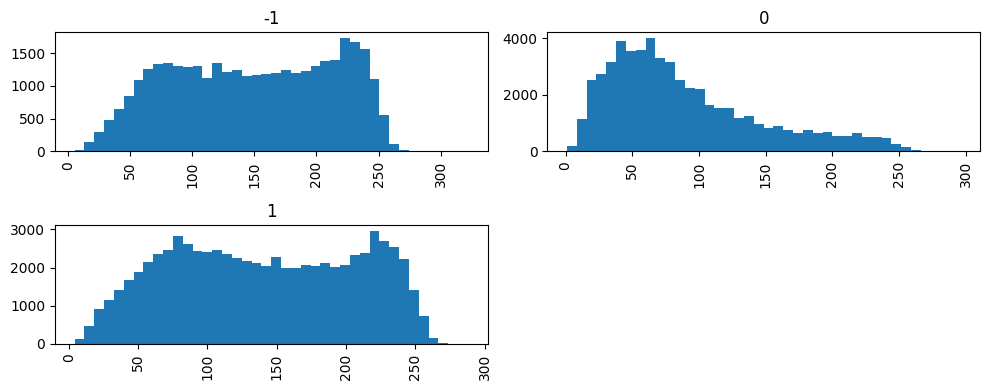

In [26]:
# Distribution of message lengths by class
df.hist(column='Tweet_Length', by='Sentiment', bins=40, figsize=(10, 4))
plt.tight_layout()
plt.show()

#Text Preprocessing.

#Removing punctuation and converting to lower case.

In [29]:
def remove_punct(text):
    return ''.join(ch for ch in text if ch not in string.punctuation)

def convert_lower(text):
    return text.lower()

df['Tweet_clean'] = df['Tweet'].astype(str).apply(remove_punct)
df['Tweet_clean'] = df['Tweet_clean'].astype(str).apply(convert_lower)
df.head(8)

,Tweet,Sentiment,Tweet_Length,Tweet_clean
1,when modi promised âminimum government maxim...,-1,214,when modi promised âminimum government maxim...
2,talk all the nonsense and continue all the dra...,0,68,talk all the nonsense and continue all the dra...
3,what did just say vote for modi welcome bjp t...,1,117,what did just say vote for modi welcome bjp t...
4,asking his supporters prefix chowkidar their n...,1,212,asking his supporters prefix chowkidar their n...
5,answer who among these the most powerful world...,1,81,answer who among these the most powerful world...
6,kiya tho refresh maarkefir comment karo,0,40,kiya tho refresh maarkefir comment karo
7,surat women perform yagna seeks divine grace f...,0,76,surat women perform yagna seeks divine grace f...
8,this comes from cabinet which has scholars lik...,0,84,this comes from cabinet which has scholars lik...


In [30]:
df['Sentiment'].value_counts()

,count
Sentiment,
1,72250
0,55213
-1,35510


#Splitting into Train and Test Data

In [32]:
X = df['Tweet_clean']
Y = df['Sentiment']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

print('Train size:', len(X_train))
print('Test  size:', len(X_test))

Train size: 130384
Test  size: 32596


#Vectorisation — Bag of Words (CountVectorizer)

In [33]:
#Count Vectorize and remove stopwords.
CV = CountVectorizer(stop_words='english')
X_train_cv = CV.fit_transform(X_train)  # fit + transform
X_test_cv  = CV.transform(X_test)        # transform only — same vocabulary

print('Vocabulary size:', len(CV.vocabulary_))
print('Train shape    :', X_train_cv.shape)
print('Test  shape    :', X_test_cv.shape)

Vocabulary size: 94734
Train shape    : (130384, 94734)
Test  shape    : (32596, 94734)


In [34]:
feature_names = CV.get_feature_names_out()
print('Total features:', len(feature_names))
print('Sample words  :', feature_names[:100]) #Printing First 100 tokens from the Vocaborary.

Total features: 94734
Sample words  : ['000' '0000' '00000' '000000' '0000000' '00000000' '000000000'
 '0000000000'
 '00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001'
 '0000000001' '0001' '0005' '000kwkajhatka' '000s' '000â' '001' '002'
 '007' '007james' '00905523223324' '00s' '0100am' '0104also' '0118' '015'
 '018sec' '01992017' '021' '0229' '025' '0250' '03122016' '032' '032019i'
 '0327' '0339' '034' '0351' '03jalgaon' '0404health' '041' '0414'
 '0420462818' '04280' '0448pm' '047' '048' '04yrs' '0500' '0554' '05yrs'
 '06042019' '0607' '0609' '062' '06crore' '06mar2019' '0700' '070319'
 '070801z' '07102001' '072' '074223z' '07989964299' '080' '0800' '081'
 '081116' '081127z' '089' '08th' '090' '0914' '092807z' '0930' '0945'
 '09555560725' '09999150812' '09th' '0lease' '0pposed' '0seats' '0the'
 '100' '1000' '10000' '100000' '1000000' '10000000' '1000000000'
 '1000000000000000' '100000000

#Training the model — Multinomial Naive Bayes.

In [ ]:
#X_train_cv[5]

In [38]:
Y_train.head(50)

,Sentiment
63467,0
13952,0
98299,1
9879,0
74418,-1
46162,1
58073,1
42273,0
90737,0
52354,1


In [39]:
Y_train = Y_train.fillna(Y_train.mode()[0])

In [40]:
NB = MultinomialNB()
NB.fit(X_train_cv, Y_train)
#alpha is used for Laplace smooothing.

MultinomialNB()

In [41]:
Y_Predict = NB.predict(X_test_cv)
Y_Predict

array(['0', '-1', '-1', ..., '1', '-1', '0'], dtype='<U2')

In [42]:
y_cat_variable = pd.Categorical(Y_Predict).rename_categories({'-1':"Negative Sentiment",'0':"Neutral Sentiment",'1':"Positive Sentiment"})
y_cat_variable


['Neutral Sentiment', 'Negative Sentiment', 'Negative Sentiment', 'Positive Sentiment', 'Neutral Sentiment', ..., 'Positive Sentiment', 'Neutral Sentiment', 'Positive Sentiment', 'Negative Sentiment', 'Neutral Sentiment']
Length: 32596
Categories (3, object): ['Negative Sentiment', 'Neutral Sentiment', 'Positive Sentiment']

#Calculating Accuracy.

In [47]:
accuracy = accuracy_score(Y_test, Y_Predict) * 100
print(f'MultinomialNB Accuracy using Count Vectorizer: {accuracy:.2f}%')

MultinomialNB Accuracy using Count Vectorizer: 70.07%


In [48]:
 #Per-Class F1 Score (Returns an array of scores for each class)
per_class_f1 = f1_score(Y_test, Y_Predict, average=None)
print(f"Per-Class F1 Scores: {per_class_f1}")

Per-Class F1 Scores: [0.64649583 0.65921909 0.74411173]


In [49]:
#Per-class Recall (Returns an array containing recall for each class)
recall_per_class = recall_score(Y_test, Y_Predict, average=None)
print(f"Per-Class Recall Scores: {recall_per_class}")

Per-Class Recall Scores: [0.58336816 0.55084285 0.87422652]


In [50]:
print(classification_report(Y_test,Y_Predict,target_names=['Positive Sentiment','Neutral Sentiment','Negative Sentiment']))

                    precision    recall  f1-score   support

Positive Sentiment       0.72      0.58      0.65      7179
 Neutral Sentiment       0.82      0.55      0.66     11034
Negative Sentiment       0.65      0.87      0.74     14383

          accuracy                           0.70     32596
         macro avg       0.73      0.67      0.68     32596
      weighted avg       0.72      0.70      0.69     32596



In [51]:
ConfusionMatrix = pd.DataFrame(
    confusion_matrix(Y_test, Y_Predict),
    index=['Actual Negative Sentiment', 'Actual Neutral Sentiment','Actual Positve Sentiment'],
    columns=['Predicted Negative Sentiment', 'Predicted Neutral Sentiment','Actual Positve Sentiment']
)
ConfusionMatrix

,Predicted Negative Sentiment,Predicted Neutral Sentiment,Actual Positve Sentiment
Actual Negative Sentiment,4188,468,2523
Actual Neutral Sentiment,640,6078,4316
Actual Positve Sentiment,949,860,12574


#Testing on a New Tweet.

In [52]:
def classify_tweet(tweet):
    cleaned  = remove_punct(tweet)
    cleaned = convert_lower(cleaned)
    features = CV.transform([cleaned])
    Predict = NB.predict(features)[0]
    if(Predict == '-1'):
      Sentiment='Negative Sentiment'
    elif(Predict=='0'):
      Sentiment="Neutral Sentiment"
    elif(Predict=='1'):
      Sentiment="Positive Sentiement"
    return Sentiment

#-1-Negative,
#0-Neutral
#+1-Positive(+1)

In [53]:
#Neutral Sentiment Tweet.
Tweet1='this comes from cabinet which has scholars like modi smriti and hema time introspect'

In [54]:
sentiment=classify_tweet(Tweet1)
print(sentiment)

Neutral Sentiment


In [ ]:
#Tweet1='vote such party and leadershipwho can take fast and firm action none other than narendra damodardas modi and bjp party'

In [55]:
Tweet2='talk all the nonsense and continue all the drama will vote for modi'

In [56]:
sentiment=classify_tweet(Tweet2)
print(sentiment)

Positive Sentiement


In [57]:
#Neutral Sentiement.
Tweet2="one vote can make all the difference anil kapoor answers modis election 2019 clarion call extends support his vote kar campaign"

In [58]:
sentiment=classify_tweet(Tweet2)
print(sentiment)

Neutral Sentiment


In [59]:
Tweet3="with firm belief the leadership shri narendra modi bjp entering into politics given form file nomination for the khammam parliamentary seat proceeding khammam today"
#negative Tweet Sentiment.

In [60]:
sentiment=classify_tweet(Tweet3)
print(sentiment)

Negative Sentiment


In [61]:
Tweet4="	hope tuthukudi people would prefer honest well behaved nationalist courageous likly minister modi cabinet vote benifit thuthukudi"
#Positive Tweet Sentiment

In [62]:
sentiment=classify_tweet(Tweet4)
print(sentiment)

Positive Sentiement


In [63]:
#Positive Sentiment Tweet.
Tweet5='answer who among these the most powerful world leader today trump putin modi may'

In [64]:
sentiment=classify_tweet(Tweet5)
print(sentiment)

Positive Sentiement


#Vectorisation —TF-IDF Vectorization.

In [66]:
tf = TfidfVectorizer(max_features=1000)

X_train_tf = tf.fit_transform(X_train)
X_test_tf  = tf.transform(X_test)

# FIX 4: get_feature_names_out() replaces deprecated get_feature_names()
print('TF-IDF features:', len(tf.get_feature_names_out()))
print('Train shape     :', X_train_tf.shape)
print('Test  shape     :', X_test_tf.shape)

TF-IDF features: 1000
Train shape     : (130384, 1000)
Test  shape     : (32596, 1000)


In [67]:
#Y_train=Y_train.fillna(Y_train.mode())
#Y_train.dtype
Y_train = Y_train.fillna(Y_train.mode()[0])

In [68]:
NB = MultinomialNB()
NB.fit(X_train_tf, Y_train)

MultinomialNB()

In [ ]:
'''has_nan = Y_train.isna().any()
print(has_nan)'''

True


In [69]:
Y_Predict = NB.predict(X_test_tf)
Y_Predict

array(['0', '1', '1', ..., '1', '-1', '0'], dtype='<U2')

In [70]:
y_cat_variable = pd.Categorical(Y_Predict).rename_categories({'-1':"Negative Sentiment", '0':"Neutral Sentiment",'1':"Positive Sentiment"})
y_cat_variable
#-1-Negative,
#0-Neutral
#+1-Positive(+1)

['Neutral Sentiment', 'Positive Sentiment', 'Positive Sentiment', 'Neutral Sentiment', 'Neutral Sentiment', ..., 'Positive Sentiment', 'Neutral Sentiment', 'Positive Sentiment', 'Negative Sentiment', 'Neutral Sentiment']
Length: 32596
Categories (3, object): ['Negative Sentiment', 'Neutral Sentiment', 'Positive Sentiment']

In [71]:
accuracy = accuracy_score(Y_test, Y_Predict) * 100
print(f'Multinomial Naive Bayes Accuracy using TF IDF: {accuracy:.2f}%')

Multinomial Naive Bayes Accuracy using TF IDF: 69.97%


In [72]:
 #Per-Class F1 Score (Returns an array of scores for each class)
per_class_f1 = f1_score(Y_test, Y_Predict, average=None)
print(f"Per-Class F1 Scores: {per_class_f1}")

Per-Class F1 Scores: [0.46679081 0.71957469 0.75261927]


In [73]:
#Per-class Recall (Returns an array containing recall for each class)
recall_per_class = recall_score(Y_test, Y_Predict, average=None)

In [74]:
print(classification_report(Y_test, Y_Predict, target_names=['-1','0','1']))

              precision    recall  f1-score   support

          -1       0.91      0.31      0.47      7179
           0       0.76      0.68      0.72     11034
           1       0.64      0.91      0.75     14383

    accuracy                           0.70     32596
   macro avg       0.77      0.63      0.65     32596
weighted avg       0.74      0.70      0.68     32596



In [75]:
ConfusionMatrix = pd.DataFrame(
    confusion_matrix(Y_test, Y_Predict),
    index=['Actual Negative Sentiment', 'Actual Neutral Sentiment','Actual Positve Sentiment'],
    columns=['Predicted Negative Sentiment', 'Predicted Neutral Sentiment','Actual Positve Sentiment']
)
ConfusionMatrix

,Predicted Negative Sentiment,Predicted Neutral Sentiment,Actual Positve Sentiment
Actual Negative Sentiment,2256,1181,3742
Actual Neutral Sentiment,38,7512,3484
Actual Positve Sentiment,193,1152,13038


#Testing on a New Tweet.

In [76]:
def classify_tweet(tweet):
    cleaned  = remove_punct(tweet)
    cleaned = convert_lower(cleaned)
    features = tf.transform([cleaned])
    Predict = NB.predict(features)[0]
    if(Predict == '-1'):
      Sentiment='Negative Sentiment'
    elif(Predict=='0'):
      Sentiment="Neutral Sentiment"
    elif(Predict=='1'):
      Sentiment="Positive Sentiement"
    return Sentiment

#-1-Negative,
#0-Neutral
#+1-Positive(+1)


In [79]:
#Neutral Sentiment Tweet.
Tweet1='this comes from cabinet which has scholars like modi smriti and hema time introspect'

In [80]:
sentiment=classify_tweet(Tweet1)
print(sentiment)

Positive Sentiement


In [81]:
#Neutral Sentiement Tweet.
Tweet2="one vote can make all the difference anil kapoor answers modis election 2019 clarion call extends support his vote kar campaign"

In [82]:
sentiment=classify_tweet(Tweet2)
print(sentiment)

Neutral Sentiment


In [85]:
Tweet3="with firm belief the leadership shri narendra modi bjp entering into politics given form file nomination for the khammam parliamentary seat proceeding khammam today"
#negative Tweet Sentiment.

In [86]:
sentiment=classify_tweet(Tweet3)
print(sentiment)

Positive Sentiement


In [87]:
Tweet4="	hope tuthukudi people would prefer honest well behaved nationalist courageous likly minister modi cabinet vote benifit thuthukudi"
#Positive Tweet Sentiment

In [88]:
sentiment=classify_tweet(Tweet4)
print(sentiment)

Positive Sentiement


In [89]:
#Positive Sentiment Tweet.
Tweet5='answer who among these the most powerful world leader today trump putin modi may'

In [90]:
sentiment=classify_tweet(Tweet5)
print(sentiment)

Positive Sentiement
